Component 3
## Scenario Engine and Portfolio Stress Transmission

This notebook implements a portfolio stress-testing engine by combining the loan-level PD model from Component 1 with the satellite regression developed in Component 2.

This component is a **transmission mechanism**. It takes different macroeconomic scenarios, applies the satellite model's **estimated** sensitivities, and projects the effect on portfolio defaults and
losses.

**Pipeline:** scenario unemployment path → stressed A/E multiplier → stressed PD → stressed
default rate → illustrative expected loss (EL).


**Design choices:**

- **Channel:** unemployment-only, using the satellite's *own estimated* elasticity (the one
  robustly identified channel). A labeled multi-factor extension using benchmark sensitivities
  for the unidentified spread/GDP channels is sketched at the end.

- **Scenarios:** three unemployment scenario paths (with actual FRED UNRATE history):
   - baseline: flat unemployment
   - adverse: 2001 recession quarterly-change profile
   - severe: 2008–2009 GFC quarterly-change profile

- **Population:** the full eligible scored loan set from Component 1. In production this would be
  the *current outstanding portfolio* as of the scenario start date.

- **EL assumptions (illustrative, flat):** LGD = 0.80 (unsecured consumer), EAD = `loan_amnt`
  (original loan amount). Empirical LGD estimation, amortized EAD, and LGD stressing are
  natural extensions.


In [43]:
import numpy as np
import pandas as pd

# ----------------------------
# Load Component 1 scored loans and Component 2 coefficients
# ----------------------------

scored = pd.read_parquet('scored_loan_level_pd.parquet')
coef = pd.read_csv('satellite_coefficients_baseline.csv') 

print(coef[
    (coef['target']   == 'calibrated') &
    (coef['model_id'] == 'M1_unemp') &
    (coef['term']     == 'unrate_diff_l1')
][['target', 'model_id', 'term', 'coef', 'std_err_HAC', 'p_value_HAC']])


       target  model_id            term      coef  std_err_HAC   p_value_HAC
1  calibrated  M1_unemp  unrate_diff_l1  0.203376      0.02824  5.949953e-13


In [44]:
# ------------------------------------------------------------
# Artifact sub-folder: ALL Component 3 tables and figures go here.
# ------------------------------------------------------------
import os
ARTIFACT_DIR = "artifacts_component3"
os.makedirs(ARTIFACT_DIR, exist_ok=True)
print("Artifacts ->", os.path.abspath(ARTIFACT_DIR))


Artifacts -> c:\Users\shanx\Dropbox\STG\STG26CODES\Git\Projects\StressTesting\artifacts_component3


### 1. Read Transmission Coefficient

In [45]:
# Read M1 calibrated unemployment coefficient 

mask = (
    (coef['sample'] == 'baseline_full_age_mix') &
    (coef['target'] == 'calibrated') &
    (coef['model_id'] == 'M1_unemp') &
    (coef['term'] == 'unrate_diff_l1')
)

row = coef[mask]
assert len(row) == 1, f'Expected exactly one M1 calibrated unemployment coefficient, found {len(row)}'
    #Stop the code unless row contains exactly one item.


beta_unemp = float(row['coef'].iloc[0]) # M1 calibrated unemployment coefficient


print(f'Transmission coefficient (M1 calibrated, Δunemployment): beta = {beta_unemp:.4f}')

print(f'Semi-elasticity: a +1pp larger rise in unemployment scales the multiplier by exp(beta) = {np.exp(beta_unemp):.4f}')
print(f'  (i.e. ~{100*(np.exp(beta_unemp)-1):.1f}% higher A/E multiplier per +1pp unemployment shock)')

Transmission coefficient (M1 calibrated, Δunemployment): beta = 0.2034
Semi-elasticity: a +1pp larger rise in unemployment scales the multiplier by exp(beta) = 1.2255
  (i.e. ~22.6% higher A/E multiplier per +1pp unemployment shock)


### 2. Define Scenario Paths

This step constructs the unemployment paths used in the scenario engine.

I pull the actual monthly
unemployment series (FRED **UNRATE**), aggregate to quarterly on an **end-of-quarter** basis —
matching how `unrate` was constructed in the Component 2 satellite — and
read the quarterly-change profile of two historical episodes directly from the data:

- **Adverse scenario:** the 2001 recession unemployment path
- **Severe scenario:** the 2008–2009 Global Financial Crisis unemployment path

Then the historical quarterly changes are applied to a common starting unemployment rate of 4.0%:

- Baseline: unemployment stays flat at 4.0%
- Adverse: follows the 2001 recession change profile
- Severe: follows the GFC change profile

This produces both scenario unemployment levels and quarterly unemployment changes for the eight-quarter stress horizon.

In [46]:
# --- Pull monthly unemployment (FRED UNRATE) and read the two episode change profiles ---
# Quarterly aggregation = END-OF-QUARTER (last month of quarter), to match how `unrate` was built
# in the Component 2 satellite (groupby(quarter).last()). Both series MUST use the same convention,
# or the estimated elasticity is applied to a differently-defined change.
FRED_CSV = ('https://fred.stlouisfed.org/graph/fredgraph.csv'
            '?id=UNRATE&cosd=2000-01-01&coed=2010-12-31')

# Offline fallback: END-OF-QUARTER UNRATE values (rounded to 0.1). Must stay end-of-quarter to match
# the live pull; paste exact values from a live run if full precision is wanted.
_fallback = {
    'rec': pd.Series([3.9, 4.3, 4.5, 5.0, 5.7, 5.7, 5.8, 5.7, 6.0],
           index=pd.PeriodIndex(['2000Q4','2001Q1','2001Q2','2001Q3','2001Q4',
                                 '2002Q1','2002Q2','2002Q3','2002Q4'], freq='Q')),
    'gfc': pd.Series([5.0, 5.1, 5.6, 6.1, 7.3, 8.7, 9.5, 9.8, 9.9],
           index=pd.PeriodIndex(['2007Q4','2008Q1','2008Q2','2008Q3','2008Q4',
                                 '2009Q1','2009Q2','2009Q3','2009Q4'], freq='Q')),
}

def _quarterly_unrate():
    raw = pd.read_csv(FRED_CSV)
    raw.columns = ['date', 'unrate']                         # FRED returns (date, value)
    raw['date']   = pd.to_datetime(raw['date'])
    raw['unrate'] = pd.to_numeric(raw['unrate'], errors='coerce')
    raw = raw.dropna()
    raw['q'] = raw['date'].dt.to_period('Q')
    return raw.groupby('q')['unrate'].last()                 # END-OF-QUARTER value

try:
    q     = _quarterly_unrate()
    gfc_q = q.loc['2007Q4':'2009Q4']
    rec_q = q.loc['2000Q4':'2002Q4']
    assert len(gfc_q) == 9 and len(rec_q) == 9, 'unexpected quarter count from FRED'
    src = 'FRED UNRATE live pull (end-of-quarter)'
except Exception as e:
    print(f'[warn] FRED pull failed ({e!r}); using rounded end-of-quarter fallback figures.')
    gfc_q, rec_q, src = _fallback['gfc'], _fallback['rec'], 'end-of-quarter fallback (rounded 0.1)'

# Quarterly CHANGE profiles (what the satellite transmits); leading anchor quarter dropped by diff()
gfc_changes = gfc_q.diff().dropna().to_numpy()    # into 2008Q1 .. 2009Q4
rec_changes = rec_q.diff().dropna().to_numpy()    # into 2001Q1 .. 2002Q4

print(f'Source: {src}')
print('GFC  quarterly levels (severe):', [round(float(x), 1) for x in gfc_q])
print('2001 quarterly levels (adverse):', [round(float(x), 1) for x in rec_q])
print('GFC  quarterly Δ (severe):', np.round(gfc_changes, 2), f'-> worst +{gfc_changes.max():.2f}pp')
print('2001 quarterly Δ (adverse):', np.round(rec_changes, 2), f'-> worst +{rec_changes.max():.2f}pp')

Source: FRED UNRATE live pull (end-of-quarter)
GFC  quarterly levels (severe): [5.0, 5.1, 5.6, 6.1, 7.3, 8.7, 9.5, 9.8, 9.9]
2001 quarterly levels (adverse): [3.9, 4.3, 4.5, 5.0, 5.7, 5.7, 5.8, 5.7, 6.0]
GFC  quarterly Δ (severe): [0.1 0.5 0.5 1.2 1.4 0.8 0.3 0.1] -> worst +1.40pp
2001 quarterly Δ (adverse): [ 0.4  0.2  0.5  0.7  0.   0.1 -0.1  0.3] -> worst +0.70pp


In [47]:
# --- Build the three scenario LEVEL paths by applying each change profile from a common start ---
horizon_q = len(gfc_changes)                 # 8 quarters
quarters  = [f'Q{i}' for i in range(1, horizon_q + 1)]
u_start   = 4.0

baseline_unemp = np.array([u_start] * horizon_q)                  # flat - no macro stress
adverse_unemp  = np.round(u_start + np.cumsum(rec_changes), 2)    # 2001 recession speed
severe_unemp   = np.round(u_start + np.cumsum(gfc_changes), 2)    # GFC 2008-09 speed

scenario = pd.DataFrame({
    'quarter': quarters,
    'baseline_unemp': baseline_unemp,
    'adverse_unemp':  adverse_unemp,
    'severe_unemp':   severe_unemp,
})
for col in ['baseline_unemp', 'adverse_unemp', 'severe_unemp']:
    scenario[col.replace('_unemp', '_dunemp')] = np.diff(
        np.concatenate([[u_start], scenario[col].to_numpy()])
    )

print('Scenario paths (levels and quarterly changes):')
print(scenario.round(2).to_string(index=False))
print(f'\nPeaks - adverse {adverse_unemp.max():.1f}% (worst Δ +{rec_changes.max():.2f}pp), '
      f'severe {severe_unemp.max():.1f}% (worst Δ +{gfc_changes.max():.2f}pp).')

Scenario paths (levels and quarterly changes):
quarter  baseline_unemp  adverse_unemp  severe_unemp  baseline_dunemp  adverse_dunemp  severe_dunemp
     Q1             4.0            4.4           4.1              0.0             0.4            0.1
     Q2             4.0            4.6           4.6              0.0             0.2            0.5
     Q3             4.0            5.1           5.1              0.0             0.5            0.5
     Q4             4.0            5.8           6.3              0.0             0.7            1.2
     Q5             4.0            5.8           7.7              0.0             0.0            1.4
     Q6             4.0            5.9           8.5              0.0             0.1            0.8
     Q7             4.0            5.8           8.8              0.0            -0.1            0.3
     Q8             4.0            6.1           8.9              0.0             0.3            0.1

Peaks - adverse 6.1% (worst Δ +0.70pp), sev

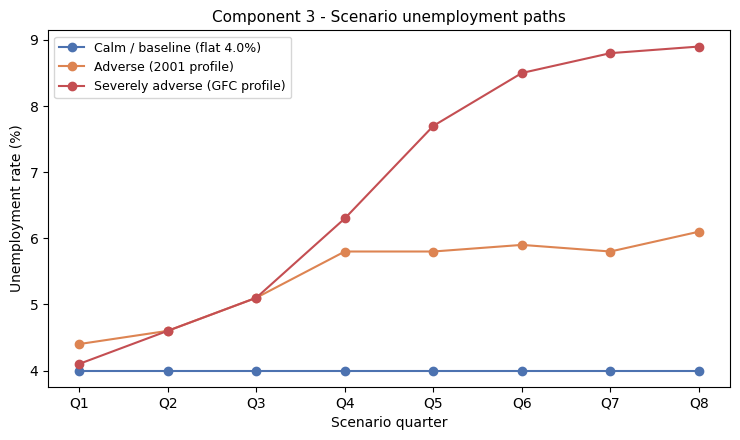

Saved -> table3.1_scenario_unemployment_paths.csv, figure3.1_scenario_unemployment_paths.png


In [48]:
# Section 2 outputs — Table 3.1 + Figure 3.1 (scenario unemployment paths)
import matplotlib.pyplot as plt

# Table 3.1 — scenario unemployment paths
scenario.to_csv(os.path.join(ARTIFACT_DIR, 'table3.1_scenario_unemployment_paths.csv'), index=False)

# Figure 3.1 — scenario unemployment paths (levels by quarter)
_c   = {'baseline': '#4C72B0', 'adverse': '#DD8452', 'severe': '#C44E52'}
_lab = {'baseline': 'Calm / baseline (flat 4.0%)',
        'adverse':  'Adverse (2001 profile)',
        'severe':   'Severely adverse (GFC profile)'}

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(scenario['quarter'], scenario['baseline_unemp'], marker='o', color=_c['baseline'], label=_lab['baseline'])
ax.plot(scenario['quarter'], scenario['adverse_unemp'],  marker='o', color=_c['adverse'],  label=_lab['adverse'])
ax.plot(scenario['quarter'], scenario['severe_unemp'],   marker='o', color=_c['severe'],   label=_lab['severe'])

ax.set_ylabel('Unemployment rate (%)')
ax.set_xlabel('Scenario quarter')
ax.set_title('Component 3 - Scenario unemployment paths', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'figure3.1_scenario_unemployment_paths.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> table3.1_scenario_unemployment_paths.csv, figure3.1_scenario_unemployment_paths.png')


### 3. Stressed A/E Multipliers 

This step translates each scenario unemployment path into the quarterly PD stress multiplier m_t.

The satellite regression coefficient on unemployment, `beta_unemp`, is applied to the **excess quarterly unemployment change** relative to the flat baseline. 

`m_t = exp(beta_unemp * excess_dunemp_lag1)`

The resulting `mt` table gives the per-quarter multiplier path for all three baseline, adverse, and severe scenarios. 
The **peak** (worst quarter) of each is the stress factor applied to portfolio PDs.

In [49]:
# Per-quarter stress multiplier (mt) for each scenario, relative to the flat baseline.
paths = {'baseline': baseline_unemp, 'adverse': adverse_unemp, 'severe': severe_unemp}

mt = pd.DataFrame(index=quarters); mt.index.name = 'quarter'
peak_mult = {}
for name, u in paths.items():
    dunemp      = np.diff(np.concatenate([[u_start], u]))                 # quarterly change in this path
    excess      = dunemp - scenario['baseline_dunemp'].to_numpy()        # excess over flat baseline
    excess_lag1 = pd.Series(excess).shift(1).fillna(0.0).to_numpy()      # one-quarter lag
    mt[name]    = np.exp(beta_unemp * excess_lag1)                       # stress multiplier path
    peak_mult[name] = float(mt[name].max())

print('Per-quarter stress multiplier (mt) by scenario:')
print(mt.round(4).to_string())

print('\nPeak single-quarter stress multiplier by scenario:')
for name in paths:
    print(f'  {name:8s}: {peak_mult[name]:.4f}')

# Headline = severely-adverse
peak_stress_multiplier = peak_mult['severe']
print(f'\nHeadline (severely-adverse) peak stress multiplier: {peak_stress_multiplier:.4f}')

Per-quarter stress multiplier (mt) by scenario:
         baseline  adverse  severe
quarter                           
Q1            1.0   1.0000  1.0000
Q2            1.0   1.0848  1.0205
Q3            1.0   1.0415  1.1070
Q4            1.0   1.1070  1.1070
Q5            1.0   1.1530  1.2764
Q6            1.0   1.0000  1.3294
Q7            1.0   1.0205  1.1767
Q8            1.0   0.9799  1.0629

Peak single-quarter stress multiplier by scenario:
  baseline: 1.0000
  adverse : 1.1530
  severe  : 1.3294

Headline (severely-adverse) peak stress multiplier: 1.3294


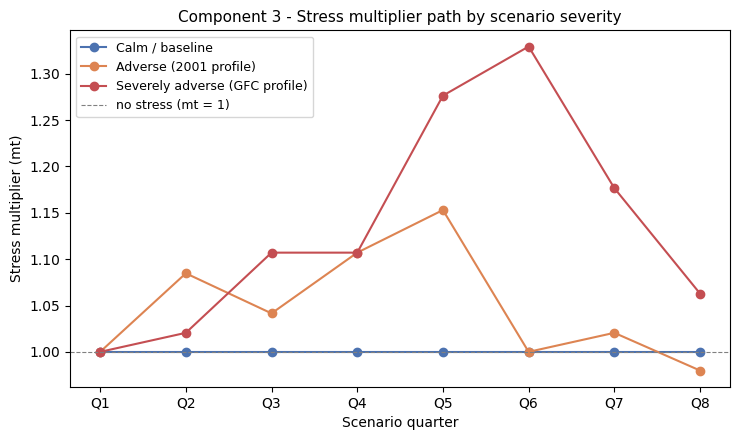

Saved -> table3.2_multiplier_paths.csv, figure3.2_multiplier_paths.png


In [50]:
# Section 3 outputs — Table 3.2 + Figure 3.2 (stress multiplier paths)
import matplotlib.pyplot as plt

# Table 3.2 — quarterly stress multiplier paths
mt.to_csv(os.path.join(ARTIFACT_DIR, 'table3.2_multiplier_paths.csv'))

# Figure 3.2 — stress multiplier path by scenario severity
colors = {'baseline': '#4C72B0', 'adverse': '#DD8452', 'severe': '#C44E52'}
labels = {'baseline': 'Calm / baseline', 'adverse': 'Adverse (2001 profile)', 'severe': 'Severely adverse (GFC profile)'}

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name in paths:
    ax.plot(quarters, mt[name], marker='o', color=colors[name], label=labels[name])

ax.axhline(1.0, color='grey', lw=0.8, ls='--', label='no stress (mt = 1)')
ax.set_ylabel('Stress multiplier (mt)')
ax.set_xlabel('Scenario quarter')
ax.set_title('Component 3 - Stress multiplier path by scenario severity', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'figure3.2_multiplier_paths.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> table3.2_multiplier_paths.csv, figure3.2_multiplier_paths.png')


### 4. Stressed Default Rate 

This step applies the scenario stress multipliers to the calibrated loan-level PDs and summarizes the resulting portfolio default rates.

I use the calibrated 24-month PD as the primary PD measure:  
`pd24m_hat_calibrated`


Each loan's stressed 24-month PD is calculated by multiplying its calibrated baseline PD by the scenario's peak stress multiplier (capped at 1): 
`stressed_pd_24m = min(pd_baseline * peak_multiplier, 1)`

Each cumulative 24-month PD is then converted into an annualized equivalent under a constant-hazard assumption: 
`annual_pd = 1 - (1 - cumulative_24m_pd) ** 0.5`

The portfolio default rate is then reported as the average stressed PD across loans, with annualized default rate as the primary reporting basis and 24-month cumulative default rate shown in parentheses.

In [51]:
# Baseline book (calibrated PD primary; raw available as a sensitivity)
pd_col = 'pd24m_hat_calibrated'
book = scored[[pd_col, 'pd24m_hat_raw', 'loan_amnt']].copy()
book = book.dropna(subset=[pd_col, 'loan_amnt'])
book['pd_baseline'] = book[pd_col]
book['ead']         = book['loan_amnt']

# The PD outcome is "default within 24 months" (cumulative). Annualize each loan to a per-year
# equivalent under constant hazard. This ANNUAL rate is the primary reporting basis.
def annualize(cum_24m):
    return 1 - (1 - cum_24m) ** 0.5     # annual = 1 - (1 - cumulative_24m)^(1/2)

# Apply each scenario's PEAK multiplier to every loan, then summarize the portfolio default rate.
default_rate_24m, default_rate_annual = {}, {}
for name in paths:
    pd_stressed_24m           = np.minimum(book['pd_baseline'] * peak_mult[name], 1.0)
    default_rate_24m[name]    = float(pd_stressed_24m.mean())
    default_rate_annual[name] = float(annualize(pd_stressed_24m).mean())   # per-loan, then averaged

print(f'Loans in book: {len(book):,}\n')
print('Portfolio default rate by scenario  (ANNUAL primary; 24m cumulative in parentheses):')
for name in paths:
    da, d24 = 100*default_rate_annual[name], 100*default_rate_24m[name]
    rel = 100*(default_rate_annual[name]/default_rate_annual['baseline'] - 1)
    print(f'  {name:8s}: {da:5.2f}%/yr   ({d24:5.2f}% over 24m)   ({rel:+.1f}% vs baseline)')

Loans in book: 1,310,558

Portfolio default rate by scenario  (ANNUAL primary; 24m cumulative in parentheses):
  baseline:  7.26%/yr   (13.76% over 24m)   (+0.0% vs baseline)
  adverse :  8.45%/yr   (15.86% over 24m)   (+16.4% vs baseline)
  severe  :  9.86%/yr   (18.29% over 24m)   (+35.8% vs baseline)


### 5. Expected Loss (EL) 

This step converts stressed PDs into expected loss rates.

Expected loss is calculated using: 
`EL = PD * LGD * EAD`

An illustrative LGD of 80% is used.
The original loan amount is used as the EAD proxy so that the result is exposure-weighted across the loan book.

The result is also translated into dollar losses per $1 billion of exposure, with incremental loss shown relative to the baseline scenario.

As with the default rate, the **annual** expected-loss rate is the primary figure: each loan's PD is
annualized, then exposure-weighted into a portfolio annual EL rate (and dollars per $1B). The
24-month cumulative EL is retained as the reference basis. 


In [52]:
LGD           = 0.80
total_ead     = book['ead'].sum()
REF_PORTFOLIO = 1_000_000_000   # $1B of exposure

# Annual EL is primary: annualize each loan's stressed PD, then exposure-weight. 24m kept as reference.
el_rate_24m, el_rate_annual = {}, {}
for name in paths:
    pd_stressed_24m      = np.minimum(book['pd_baseline'] * peak_mult[name], 1.0)
    pd_stressed_annual   = annualize(pd_stressed_24m)
    el_rate_24m[name]    = float((pd_stressed_24m    * LGD * book['ead']).sum() / total_ead)
    el_rate_annual[name] = float((pd_stressed_annual * LGD * book['ead']).sum() / total_ead)

print(f'Illustrative LGD: {LGD:.2f}   |   EAD proxy: original loan_amnt   |   PD basis: {pd_col} (primary)')
print('Expected loss as a RATE (% of EAD), ANNUAL primary; 24m cumulative in parentheses.\n')
print('Expected loss by scenario:')
for name in paths:
    ann, c24 = el_rate_annual[name], el_rate_24m[name]
    dollars  = ann * REF_PORTFOLIO / 1e6
    incr     = (ann - el_rate_annual['baseline']) * REF_PORTFOLIO / 1e6
    rel_el   = 100 * (el_rate_annual[name] / el_rate_annual['baseline'] - 1)
    print(f'  {name:8s}:  {100*ann:5.2f}%/yr  ({100*c24:5.2f}% over 24m)  |  ${dollars:6.1f}M per $1B/yr  '
          f'|  incremental ${incr:+6.1f}M ({rel_el:+.1f}%) vs baseline')

Illustrative LGD: 0.80   |   EAD proxy: original loan_amnt   |   PD basis: pd24m_hat_calibrated (primary)
Expected loss as a RATE (% of EAD), ANNUAL primary; 24m cumulative in parentheses.

Expected loss by scenario:
  baseline:   5.95%/yr  (11.25% over 24m)  |  $  59.5M per $1B/yr  |  incremental $  +0.0M (+0.0%) vs baseline
  adverse :   6.93%/yr  (12.97% over 24m)  |  $  69.3M per $1B/yr  |  incremental $  +9.8M (+16.5%) vs baseline
  severe  :   8.10%/yr  (14.96% over 24m)  |  $  81.0M per $1B/yr  |  incremental $ +21.4M (+36.0%) vs baseline


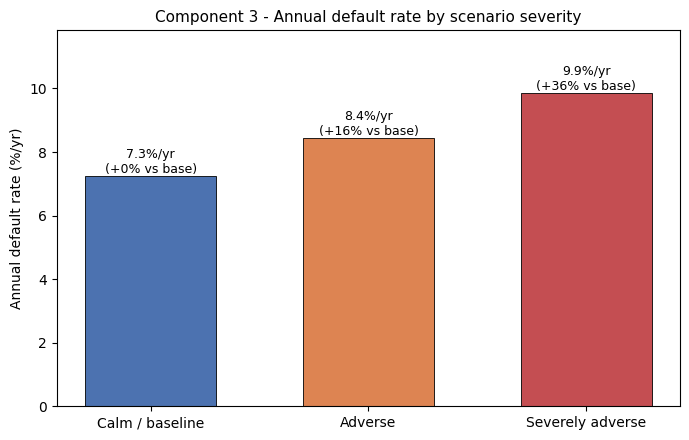

Saved -> figure3.3_default_rate_by_scenario.png


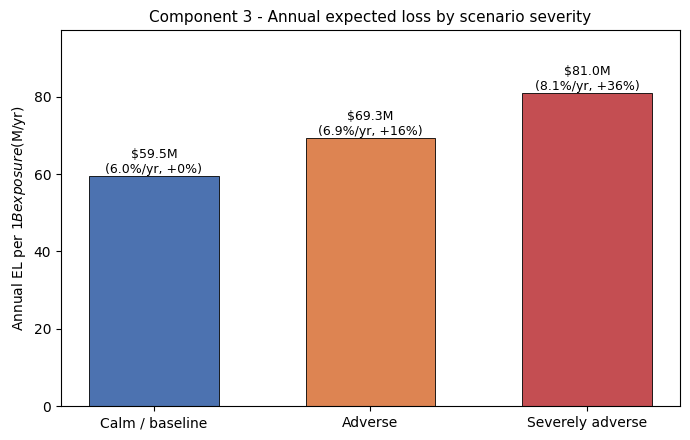

Saved -> figure3.3_default_rate_by_scenario.png, figure3.4_el_by_scenario.png


In [53]:
# Section 5 outputs — 
# Figure 3.3 (default rate) 
# Figure 3.4 (expected loss) by scenario
import matplotlib.pyplot as plt


colors = {'baseline': '#4C72B0', 'adverse': '#DD8452', 'severe': '#C44E52'}
order  = ['baseline', 'adverse', 'severe']
xlabel = ['Calm / baseline', 'Adverse', 'Severely adverse']

# ---- Figure 3.3 — annual default rate by scenario ----
fig, ax = plt.subplots(figsize=(7, 4.5))
dvals = [100 * default_rate_annual[n] for n in order]
bars = ax.bar(xlabel, dvals, color=[colors[n] for n in order],
              width=0.6, edgecolor='black', linewidth=0.6)
for b, n in zip(bars, order):
    rel = 100 * (default_rate_annual[n] / default_rate_annual['baseline'] - 1)
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f'{b.get_height():.1f}%/yr\n({rel:+.0f}% vs base)',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Annual default rate (%/yr)')
ax.set_title('Component 3 - Annual default rate by scenario severity', fontsize=11)
ax.set_ylim(0, max(dvals) * 1.20)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'figure3.3_default_rate_by_scenario.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> figure3.3_default_rate_by_scenario.png')

# ---- Figure 3.4 — annual expected loss per $1B by scenario ----
fig, ax = plt.subplots(figsize=(7, 4.5))
evals = [el_rate_annual[n] * REF_PORTFOLIO / 1e6 for n in order]
bars = ax.bar(xlabel, evals, color=[colors[n] for n in order],
              width=0.6, edgecolor='black', linewidth=0.6)
for b, n in zip(bars, order):
    rel = 100 * (el_rate_annual[n] / el_rate_annual['baseline'] - 1)
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f'${b.get_height():,.1f}M\n({100*el_rate_annual[n]:.1f}%/yr, {rel:+.0f}%)',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Annual EL per $1B exposure ($M/yr)')
ax.set_title('Component 3 - Annual expected loss by scenario severity', fontsize=11)
ax.set_ylim(0, max(evals) * 1.20)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'figure3.4_el_by_scenario.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> figure3.3_default_rate_by_scenario.png, figure3.4_el_by_scenario.png')



### 6. Scenario Summary

In [54]:
# ---- Relative uplifts (vs baseline), computed on each basis explicitly ----
default_rel_annual = {n: 100*(default_rate_annual[n]/default_rate_annual['baseline'] - 1) for n in paths}
default_rel_24m    = {n: 100*(default_rate_24m[n]/default_rate_24m['baseline'] - 1)       for n in paths}
el_rel_annual      = {n: 100*(el_rate_annual[n]/el_rate_annual['baseline'] - 1)           for n in paths}
el_rel_24m         = {n: 100*(el_rate_24m[n]/el_rate_24m['baseline'] - 1)                 for n in paths}

summary = pd.DataFrame({
    'peak_unemp_pct':           {n: float(np.max(paths[n])) for n in paths},
    'peak_stress_multiplier':   {n: peak_mult[n]            for n in paths},
    # PRIMARY: annual-equivalent
    'default_rate_annual_pct':  {n: 100*default_rate_annual[n] for n in paths},
    'default_rel_annual_pct':   default_rel_annual,
    'el_rate_annual_pct':       {n: 100*el_rate_annual[n]      for n in paths},
    'el_rel_annual_pct':        el_rel_annual,
    'el_annual_per_1bn_$m':     {n: el_rate_annual[n]*REF_PORTFOLIO/1e6 for n in paths},
    # REFERENCE: 24-month cumulative
    'default_rate_24m_pct':     {n: 100*default_rate_24m[n]    for n in paths},
    'default_rel_24m_pct':      default_rel_24m,
    'el_rate_24m_pct':          {n: 100*el_rate_24m[n]         for n in paths},
    'el_rel_24m_pct':           el_rel_24m,
})
summary.index.name = 'scenario'

base_ann = summary.loc['baseline', 'el_annual_per_1bn_$m']
summary['incremental_el_annual_vs_baseline_$m'] = summary['el_annual_per_1bn_$m'] - base_ann

print('=== Component 3 — Scenario summary (ANNUAL primary; anchored to 2001 / GFC trajectories) ===\n')

print('Annual-equivalent (primary):')
print(summary[['peak_unemp_pct','peak_stress_multiplier',
               'default_rate_annual_pct','default_rel_annual_pct',
               'el_rate_annual_pct','el_rel_annual_pct',
               'el_annual_per_1bn_$m','incremental_el_annual_vs_baseline_$m']].round(2).to_string())

print('\n24-month cumulative (reference):')
print(summary[['default_rate_24m_pct','default_rel_24m_pct',
               'el_rate_24m_pct','el_rel_24m_pct']].round(2).to_string())

# Summary table -> single artifact folder (Table 3.3)
summary.to_csv(os.path.join(ARTIFACT_DIR, 'table3.3_scenario_summary.csv'))
print('\nSaved -> artifacts_component3/table3.3_scenario_summary.csv')

print(f"\nHeadline (severely-adverse, GFC-paced): annual EL {100*el_rate_annual['severe']:.2f}%/yr "
      f"(${summary.loc['severe','el_annual_per_1bn_$m']:.1f}M per $1B/yr); the shock raises annual expected loss "
      f"by +{el_rel_annual['severe']:.0f}% (peak multiplier {peak_mult['severe']:.2f}).")

=== Component 3 — Scenario summary (ANNUAL primary; anchored to 2001 / GFC trajectories) ===

Annual-equivalent (primary):
          peak_unemp_pct  peak_stress_multiplier  default_rate_annual_pct  default_rel_annual_pct  el_rate_annual_pct  el_rel_annual_pct  el_annual_per_1bn_$m  incremental_el_annual_vs_baseline_$m
scenario                                                                                                                                                                                            
baseline             4.0                    1.00                     7.26                    0.00                5.95               0.00                 59.51                                  0.00
adverse              6.1                    1.15                     8.45                   16.42                6.93              16.49                 69.32                                  9.81
severe               8.9                    1.33                     9.86                

## Extension: Multi-factor Engine
A full supervisory scenario also moves GDP and credit spreads. The satellite did **not** identify
separate GDP or spread channels on this data, so multi-factor transmission need to use **external
benchmark sensitivities**, in an illustrative manner. The sketch below
shows how such an extension would be added; it is left unexecuted to keep the headline
result grounded in the successfully identified single (unemployment) channel.

```python
# ILLUSTRATIVE benchmark sensitivities (NOT estimated on this data):
# beta_gdp    = -0.05   # per +1pp GDP growth (loss falls as growth rises)
# beta_spread = +0.30   # per +1pp credit-spread widening
#
# stress_multiplier_mf = exp(
#     beta_unemp  * excess_dunemp_lag1
#   + beta_gdp    * excess_dgdp_lag1
#   + beta_spread * excess_dspread_lag1
# )
# ...then identical PD/default-rate/EL transmission as above.
```

Using a *published* CCAR severely-adverse scenario (which supplies jointly-consistent unemployment,
GDP, and spread paths) would be the appropriate source for this extension.

In [56]:
# Verify every expected artifact landed in the folder (and nothing in the working dir)
import os
expected = [
    'table3.1_scenario_unemployment_paths.csv',
    'table3.2_multiplier_paths.csv',
    'table3.3_scenario_summary.csv',
    'figure3.1_scenario_unemployment_paths.png',
    'figure3.2_multiplier_paths.png',
    'figure3.3_default_rate_by_scenario.png',
    'figure3.4_el_by_scenario.png',
]
present = set(os.listdir(ARTIFACT_DIR))
missing = [f for f in expected if f not in present]
print('Artifact folder:', os.path.abspath(ARTIFACT_DIR))
print('Expected:', len(expected), '| found in folder:', len(present))
print('All expected artifacts present.' if not missing else 'MISSING:')
for f in missing:
    print('  -', f)
print('\nFolder contents:')
for f in sorted(present):
    print('  ', f)

Artifact folder: c:\Users\shanx\Dropbox\STG\STG26CODES\Git\Projects\StressTesting\artifacts_component3
Expected: 7 | found in folder: 7
All expected artifacts present.

Folder contents:
   figure3.1_scenario_unemployment_paths.png
   figure3.2_multiplier_paths.png
   figure3.3_default_rate_by_scenario.png
   figure3.4_el_by_scenario.png
   table3.1_scenario_unemployment_paths.csv
   table3.2_multiplier_paths.csv
   table3.3_scenario_summary.csv
